In [1]:
!pip install transformers datasets torch matplotlib pandas tensorflow numpy accelerate sacrebleu sacremoses tensorboard nltk rouge-score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_c

In [2]:
from datasets import load_dataset
import pandas as pd

In [3]:
dataset = load_dataset("wmt16", "de-en")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/4548885 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2999 [00:00<?, ? examples/s]

In [4]:
train_subset_size = 500
validation_subset_size = 500
test_subset_size = 500

In [5]:
small_train_data = dataset['train'].shuffle(seed=42).select(range(train_subset_size))
validation_size = len(dataset['validation'])
small_validation_data = dataset['validation'].shuffle(seed=42).select(range(min(validation_subset_size, validation_size)))
test_size = len(dataset['test'])
small_test_data = dataset['test'].shuffle(seed=42).select(range(min(test_subset_size, test_size)))

In [6]:
print(pd.DataFrame(small_train_data[:5]))
print(pd.DataFrame(small_validation_data[:5]))

                                         translation
0  {'de': '(Ich weiß nicht, ob sie aber glaube ni...
1  {'de': 'Darüber hinaus fahren Sie ab einem U-B...
2  {'de': 'Nur dann, wenn wir unsere Normen selbe...
3  {'de': 'Unsere stärksten Bemühungen müssen auf...
4  {'de': 'Fälschlicherweise wird in jenem Bereic...
                                         translation
0  {'de': 'Während weiße Frauen nun die Themen Ra...
1  {'de': '"Wenn alle Stricke reißen, bin ich imm...
2  {'de': 'Es ist sehr schwer.', 'en': 'It's very...
3  {'de': 'Ehrlich gesagt, hatte ich mir gar nich...
4  {'de': 'Mitarbeiter von Perry antworteten nich...


In [7]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

In [8]:
def analyze_dataset(dataset):

    en_sentences = [ex['en'] for ex in dataset['translation']]
    de_sentences = [ex['de'] for ex in dataset['translation']]

    num_sentences = len(en_sentences)

    en_word_counts = [len(sentence.split()) for sentence in en_sentences]
    de_word_counts = [len(sentence.split()) for sentence in de_sentences]

    avg_en_length = np.mean(en_word_counts)
    avg_de_length = np.mean(de_word_counts)

    en_vocab = Counter(" ".join(en_sentences).split())
    de_vocab = Counter(" ".join(de_sentences).split())

    en_vocab_size = len(en_vocab)
    de_vocab_size = len(de_vocab)

    return {
        "num_sentences": num_sentences,
        "avg_en_length": avg_en_length,
        "avg_de_length": avg_de_length,
        "en_vocab_size": en_vocab_size,
        "de_vocab_size": de_vocab_size
    }

In [9]:
train_stats = analyze_dataset(small_train_data)
validation_stats = analyze_dataset(small_validation_data)
test_stats = analyze_dataset(small_test_data)

In [10]:
print("Training Stats:", train_stats)
print("Validation Stats:", validation_stats)
print("Test Stats:", test_stats)

Training Stats: {'num_sentences': 500, 'avg_en_length': 22.042, 'avg_de_length': 20.354, 'en_vocab_size': 4243, 'de_vocab_size': 4563}
Validation Stats: {'num_sentences': 500, 'avg_en_length': 18.148, 'avg_de_length': 17.178, 'en_vocab_size': 3770, 'de_vocab_size': 3972}
Test Stats: {'num_sentences': 500, 'avg_en_length': 19.384, 'avg_de_length': 18.392, 'en_vocab_size': 3937, 'de_vocab_size': 4238}


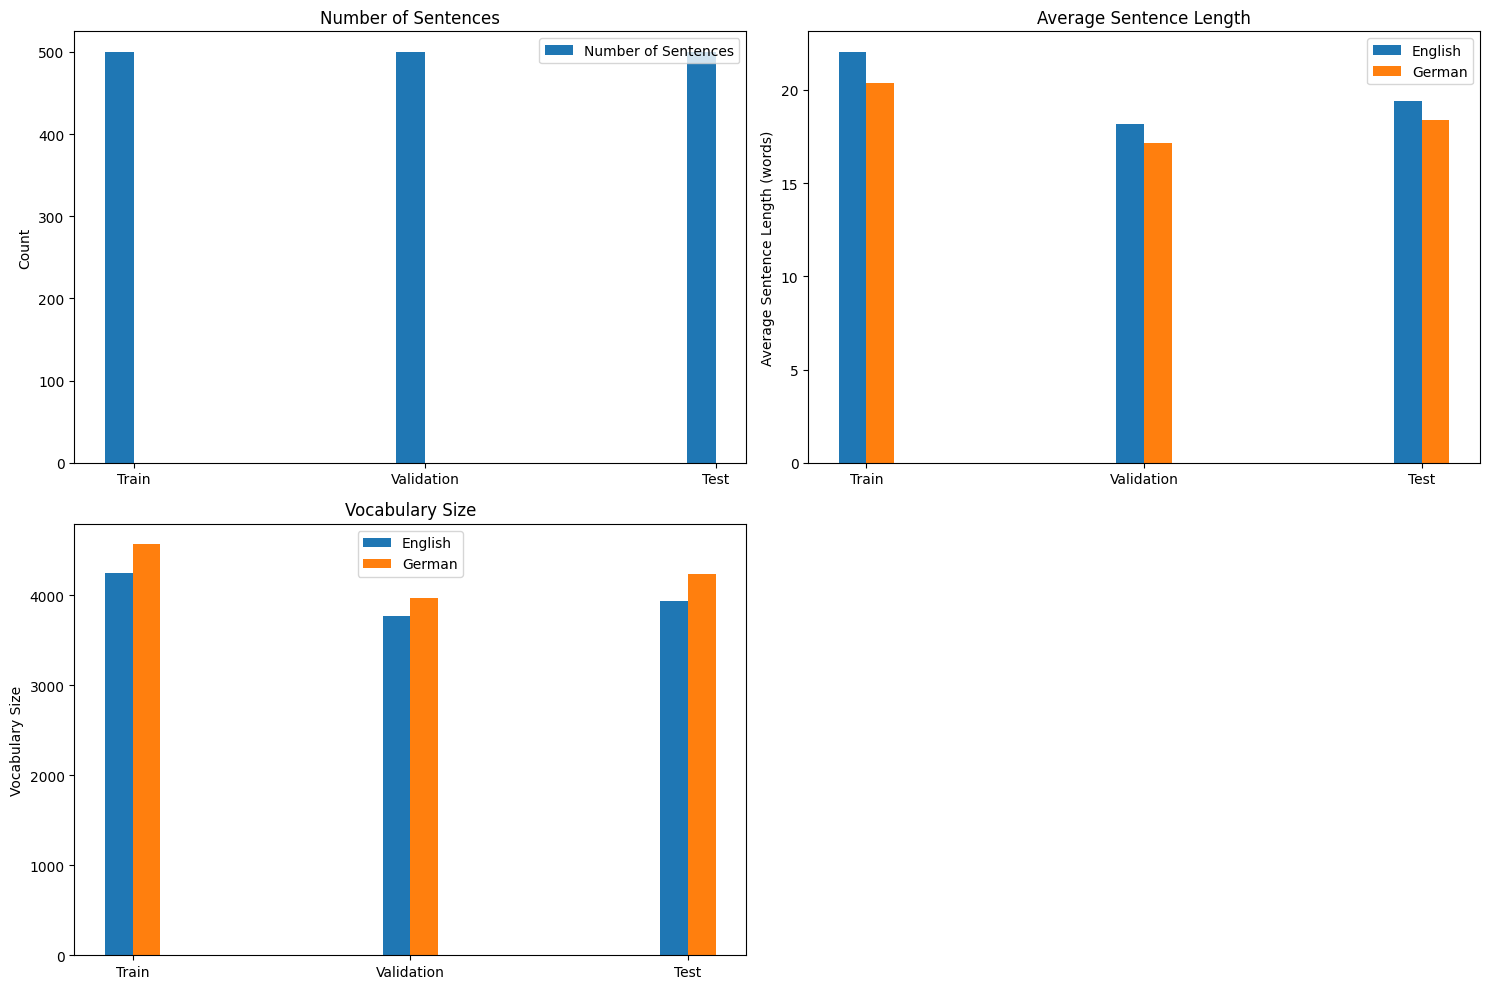

In [94]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Train', 'Validation', 'Test']
num_sentences = [train_stats['num_sentences'], validation_stats['num_sentences'], test_stats['num_sentences']]
avg_en_length = [train_stats['avg_en_length'], validation_stats['avg_en_length'], test_stats['avg_en_length']]
avg_de_length = [train_stats['avg_de_length'], validation_stats['avg_de_length'], test_stats['avg_de_length']]
en_vocab_size = [train_stats['en_vocab_size'], validation_stats['en_vocab_size'], test_stats['en_vocab_size']]
de_vocab_size = [train_stats['de_vocab_size'], validation_stats['de_vocab_size'], test_stats['de_vocab_size']]

x = np.arange(len(labels))
width = 0.1

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].bar(x - width/2, num_sentences, width, label='Number of Sentences')
ax[0, 0].set_ylabel('Count')
ax[0, 0].set_title('Number of Sentences')
ax[0, 0].set_xticks(x)
ax[0, 0].set_xticklabels(labels)
ax[0, 0].legend()

ax[0, 1].bar(x - width/2, avg_en_length, width, label='English')
ax[0, 1].bar(x + width/2, avg_de_length, width, label='German')
ax[0, 1].set_ylabel('Average Sentence Length (words)')
ax[0, 1].set_title('Average Sentence Length')
ax[0, 1].set_xticks(x)
ax[0, 1].set_xticklabels(labels)
ax[0, 1].legend()

ax[1, 0].bar(x - width/2, en_vocab_size, width, label='English')
ax[1, 0].bar(x + width/2, de_vocab_size, width, label='German')
ax[1, 0].set_ylabel('Vocabulary Size')
ax[1, 0].set_title('Vocabulary Size')
ax[1, 0].set_xticks(x)
ax[1, 0].set_xticklabels(labels)
ax[1, 0].legend()
ax[1, 1].axis('off')
fig.tight_layout()
plt.show()

In [13]:
from transformers import MarianTokenizer
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-de')
def preprocess_data(examples):
    inputs = [ex['en'] for ex in examples['translation']]
    targets = [ex['de'] for ex in examples['translation']]
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs
small_train_data = small_train_data.map(preprocess_data, batched=True)
small_validation_data = small_validation_data.map(preprocess_data, batched=True)
small_test_data = small_test_data.map(preprocess_data, batched=True)
small_train_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
small_validation_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
small_test_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:4016: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [14]:
from transformers import MarianMTModel, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

In [15]:
model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-de')

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [16]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./results_marian",
    evaluation_strategy="epoch",
    logging_strategy="steps",
    logging_steps=500,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [17]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [18]:
trainer_marian  = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=small_train_data,
    eval_dataset=small_validation_data,
    tokenizer=tokenizer,
    data_collator=data_collator
)

In [19]:
train_output = trainer_marian.train()
print("Training completed!")
trainer_marian.save_model()

/usr/local/lib/python3.10/dist-packages/transformers/data/data_collator.py:656: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss
1,No log,0.307750
2,No log,0.279597
3,No log,0.278202


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}


Training completed!


In [20]:
import torch
from torch.utils.data import DataLoader
from transformers import AdamW
from torch.nn import CrossEntropyLoss

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [21]:
import torch
from torch.utils.data import DataLoader
from transformers import AdamW
from torch.nn import CrossEntropyLoss

def evaluate_accuracy_and_loss(model, data_loader, optimizer, criterion=torch.nn.CrossEntropyLoss(), epochs=3):
    train_losses = []
    train_accuracies = []
    #print(f"evaluate_accuracy_and_loss")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for batch in data_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(model.device)
            labels = batch["labels"].to(model.device)
            outputs = model(input_ids, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            predictions = torch.argmax(outputs.logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.numel()

        train_loss = total_loss / len(data_loader)
        train_accuracy = correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")

    return train_losses, train_accuracies

In [22]:
train_loader = DataLoader(small_train_data, batch_size=16, shuffle=True)
train_losses, train_accuracies = evaluate_accuracy_and_loss(model, train_loader, optimizer, criterion)

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Epoch 1/3
Loss: 0.4872, Accuracy: 0.9082
Epoch 2/3
Loss: 0.4117, Accuracy: 0.9185
Epoch 3/3
Loss: 0.3771, Accuracy: 0.9244


In [23]:
validation_loader = DataLoader(small_validation_data, batch_size=16, shuffle=True)
val_losses, val_accuracies = evaluate_accuracy_and_loss(model, validation_loader, optimizer, criterion)

Epoch 1/3
Loss: 0.2933, Accuracy: 0.9377
Epoch 2/3
Loss: 0.2468, Accuracy: 0.9453
Epoch 3/3
Loss: 0.2101, Accuracy: 0.9528


In [24]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import torch
import matplotlib.pyplot as plt

def compute_bleu(model, dataloader, tokenizer):
    model.eval()
    all_bleu_scores = []
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(model.device)
            targets = batch["labels"].to(model.device)
            predictions = model.generate(inputs)
            decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
            decoded_targets = tokenizer.batch_decode(targets, skip_special_tokens=True)

            for target, pred in zip(decoded_targets, decoded_preds):
                target_tokens = target.split()
                pred_tokens = pred.split()
                score = sentence_bleu([target_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
                all_bleu_scores.append(score)

    average_bleu = sum(all_bleu_scores) / len(all_bleu_scores) if all_bleu_scores else 0.0
    return average_bleu

def evaluate_model(model, dataloader, loss_function):
    model.eval()
    cumulative_loss = 0
    correct_predictions = 0
    total_elements = 0
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(model.device)
            targets = batch["labels"].to(model.device)
            outputs = model(inputs, labels=targets)
            loss = outputs.loss
            cumulative_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            correct_predictions += (preds == targets).sum().item()
            total_elements += targets.numel()

    average_loss = cumulative_loss / len(dataloader)
    accuracy = correct_predictions / total_elements
    return average_loss, accuracy


def display_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    num_epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(num_epochs, train_losses, label='Training Loss')
    plt.plot(num_epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(num_epochs, train_accuracies, label='Training Accuracy')
    plt.plot(num_epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

Epoch 1/3
Train Loss: 0.3518, Train Accuracy: 0.9284
Validation Loss: 0.2528, Validation Accuracy: 0.9430
Epoch 2/3
Train Loss: 0.3243, Train Accuracy: 0.9347
Validation Loss: 0.2544, Validation Accuracy: 0.9430
Epoch 3/3
Train Loss: 0.2851, Train Accuracy: 0.9407
Validation Loss: 0.2580, Validation Accuracy: 0.9419


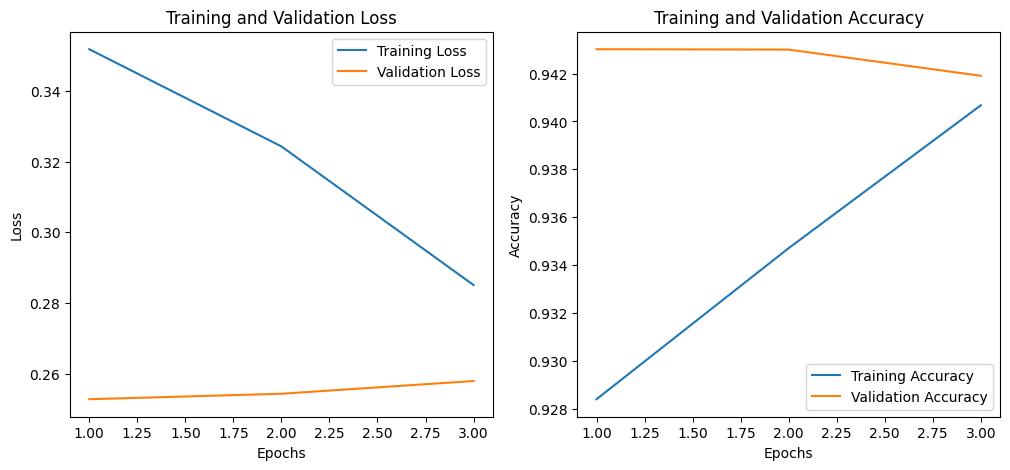

In [25]:
from torch.utils.data import DataLoader
from transformers import AdamW

def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    labels = [item['labels'] for item in batch]
    return {'input_ids': torch.stack(input_ids), 'labels': torch.stack(labels)}

train_loader = DataLoader(small_train_data, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(small_test_data, batch_size=16, shuffle=False, collate_fn=collate_fn)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

epochs = 3
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def evaluate_model(model, dataloader, loss_function):
    model.eval()
    cumulative_loss = 0
    correct_predictions = 0
    total_elements = 0
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(model.device)
            targets = batch["labels"].to(model.device)
            outputs = model(inputs, labels=targets)
            loss = outputs.loss
            cumulative_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            correct_predictions += (preds == targets).sum().item()
            total_elements += targets.numel()

    average_loss = cumulative_loss / len(dataloader)
    accuracy = correct_predictions / total_elements
    return average_loss, accuracy

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(model.device)
        labels = batch['labels'].to(model.device)
        outputs = model(input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    train_loss = total_loss / len(train_loader)
    train_accuracy = correct / total

    val_loss, val_accuracy = evaluate_model(model, test_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

display_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

In [26]:
from torch.utils.data import DataLoader
from transformers import AdamW



epochs = 3
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def train(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(model.device)
        labels = batch['labels'].to(model.device)
        outputs = model(input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    train_loss = total_loss / len(dataloader)
    return train_loss

learning_rates = [2e-5, 3e-5, 5e-5]
for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    optimizer = AdamW(model.parameters(), lr=lr)
    for epoch in range(epochs):
        train_loss = train(model, train_loader, optimizer)
        val_loss, _ = evaluate_model(model, test_loader, criterion)
        bleu_score = compute_bleu(model, test_loader, tokenizer)
        print(f"Epoch {epoch + 1}/{epochs}, Learning Rate {lr}")
        print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, BLEU Score: {bleu_score:.4f}")

Training with learning rate: 2e-05
Epoch 1/3, Learning Rate 2e-05
Train Loss: 0.2695, Validation Loss: 0.2604, BLEU Score: 0.2653
Epoch 2/3, Learning Rate 2e-05
Train Loss: 0.2394, Validation Loss: 0.2633, BLEU Score: 0.2591
Epoch 3/3, Learning Rate 2e-05
Train Loss: 0.2200, Validation Loss: 0.2675, BLEU Score: 0.2591
Training with learning rate: 3e-05
Epoch 1/3, Learning Rate 3e-05
Train Loss: 0.2054, Validation Loss: 0.2717, BLEU Score: 0.2560
Epoch 2/3, Learning Rate 3e-05
Train Loss: 0.1758, Validation Loss: 0.2766, BLEU Score: 0.2531
Epoch 3/3, Learning Rate 3e-05
Train Loss: 0.1500, Validation Loss: 0.2825, BLEU Score: 0.2538
Training with learning rate: 5e-05
Epoch 1/3, Learning Rate 5e-05
Train Loss: 0.1368, Validation Loss: 0.2890, BLEU Score: 0.2527
Epoch 2/3, Learning Rate 5e-05
Train Loss: 0.1009, Validation Loss: 0.2966, BLEU Score: 0.2518
Epoch 3/3, Learning Rate 5e-05
Train Loss: 0.0786, Validation Loss: 0.3054, BLEU Score: 0.2454


In [27]:
def generate_translations(model, dataloader, tokenizer):
    model.eval()
    translations = []
    references = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(model.device)
            labels = batch["labels"].to(model.device)
            outputs = model.generate(input_ids)
            decoded_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
            translations.extend(decoded_preds)
            references.extend(decoded_labels)
    return translations, references

def compute_bleu_score(translations, references):
    bleu_scores = []
    for ref, hyp in zip(references, translations):
        ref = ref.split()
        hyp = hyp.split()
        bleu_score = sentence_bleu([ref], hyp, smoothing_function=SmoothingFunction().method1)
        bleu_scores.append(bleu_score)
    avg_bleu_score = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0
    return avg_bleu_score

def visualize_sample_translations(translations, references, num_samples=5):
    for i in range(num_samples):
        print(f"Sample {i + 1}:")
        print(f"Reference: {references[i]}")
        print(f"Translation: {translations[i]}")
        print()

translations, references = generate_translations(model, test_loader, tokenizer)
bleu_score = compute_bleu_score(translations, references)
visualize_sample_translations(translations, references)
print(f"BLEU Score: {bleu_score:.4f}")

learning_rates = [2e-5, 3e-5, 5e-5]
for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    optimizer = AdamW(model.parameters(), lr=lr)
    for epoch in range(epochs):
        train_loss = train(model, train_loader, optimizer)


Sample 1:
Reference: Integration wird künftig viel mehr noch als heute ein Thema der ganzen Gesellschaft sein.
Translation: In Zukunft wird die Integration für die ganze Gesellschaft sogar noch mehr Thema sein als heute.

Sample 2:
Reference: Eine Rezession kam innerhalb von nur 11 Monaten nach der ersten Zinssatzerhöhung und dauerte 86 Monate.
Translation: Eine Rezession ist so schnell wie 11 Monate nach der ersten Zinserhöhung und so lange wie 86 Monate gekommen.

Sample 3:
Reference: "Wir möchten die Familien über die Jahre kennenlernen und begleiten".
Translation: "Wir wollen die Familien kennen lernen und sie in den vergangenen Jahren unterstützen."

Sample 4:
Reference: Es ist ein historisches Ereignis, weil es sieben Jahre her ist, seit die Fed Zinsen auf NULL setzte.
Translation: Das ist ein historisches Ereignis, weil es sieben Jahre her ist, seit die Fed ihre Zinsen auf Null senkt.

Sample 5:
Reference: Ich muss dafür die volle Verantwortung übernehmen", sagte er.
Translation

In [28]:
from rouge_score import rouge_scorer

def compute_rouge_score(translations, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = []
    for ref, hyp in zip(references, translations):
        score = scorer.score(ref, hyp)
        scores.append(score['rougeL'].fmeasure)  # Extract the F1 score for ROUGE-L
    avg_rouge_score = sum(scores) / len(scores) if scores else 0.0
    return avg_rouge_score

In [29]:
rouge_score = compute_rouge_score(translations, references)
visualize_sample_translations(translations, references)
print(f"ROUGE Score: {rouge_score:.4f}")

Sample 1:
Reference: Integration wird künftig viel mehr noch als heute ein Thema der ganzen Gesellschaft sein.
Translation: In Zukunft wird die Integration für die ganze Gesellschaft sogar noch mehr Thema sein als heute.

Sample 2:
Reference: Eine Rezession kam innerhalb von nur 11 Monaten nach der ersten Zinssatzerhöhung und dauerte 86 Monate.
Translation: Eine Rezession ist so schnell wie 11 Monate nach der ersten Zinserhöhung und so lange wie 86 Monate gekommen.

Sample 3:
Reference: "Wir möchten die Familien über die Jahre kennenlernen und begleiten".
Translation: "Wir wollen die Familien kennen lernen und sie in den vergangenen Jahren unterstützen."

Sample 4:
Reference: Es ist ein historisches Ereignis, weil es sieben Jahre her ist, seit die Fed Zinsen auf NULL setzte.
Translation: Das ist ein historisches Ereignis, weil es sieben Jahre her ist, seit die Fed ihre Zinsen auf Null senkt.

Sample 5:
Reference: Ich muss dafür die volle Verantwortung übernehmen", sagte er.
Translation

**-------T5 Model-------**

In [30]:
from datasets import load_dataset
import pandas as pd

In [31]:
dataset = load_dataset("wmt16", "de-en")

In [32]:
train_subset_size = 500
validation_subset_size = 500
test_subset_size = 500

In [33]:
import torch.nn as nn
from transformers import T5ForConditionalGeneration, T5Tokenizer
t5_model = T5ForConditionalGeneration.from_pretrained('t5-small')
t5_tokenizer = T5Tokenizer.from_pretrained('t5-small')

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [34]:
def preprocess_data(examples):
    inputs = [ex['en'] for ex in examples['translation']]
    targets = [ex['de'] for ex in examples['translation']]
    model_inputs = t5_tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    with t5_tokenizer.as_target_tokenizer():
        labels = t5_tokenizer(targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

small_train_data_t5 = small_train_data.map(preprocess_data, batched=True)
small_validation_data_t5 = small_validation_data.map(preprocess_data, batched=True)
small_test_data_t5 = small_test_data.map(preprocess_data, batched=True)
small_train_data_t5.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
small_validation_data_t5.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
small_test_data_t5.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:4016: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [35]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
training_args_t5 = Seq2SeqTrainingArguments(
    output_dir="./results_t5",
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=500,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
)
trainer_t5 = Seq2SeqTrainer(
    model=t5_model,
    args=training_args_t5,
    train_dataset=small_train_data_t5,
    eval_dataset=small_validation_data_t5,
    tokenizer=t5_tokenizer
)

In [36]:
train_t5_output = trainer_t5.train()
print("T5 Training completed!")

Epoch,Training Loss,Validation Loss
1,No log,7.623236
2,No log,5.137142
3,No log,4.341561


T5 Training completed!


In [37]:
output_dir_t5 = "./t5_model"
t5_model.save_pretrained(output_dir_t5)
t5_tokenizer.save_pretrained(output_dir_t5)

('./t5_model/tokenizer_config.json',
 './t5_model/special_tokens_map.json',
 './t5_model/spiece.model',
 './t5_model/added_tokens.json')

In [38]:
fine_tuned_model_t5 = T5ForConditionalGeneration.from_pretrained(output_dir_t5)
fine_tuned_tokenizer_t5 = T5Tokenizer.from_pretrained(output_dir_t5)
print("Loaeding T5 finetuned Model")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaeding T5 finetuned Model


In [39]:
import torch
from torch.utils.data import DataLoader
from transformers import AdamW
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

t5_optimizer = AdamW(fine_tuned_model_t5.parameters(), lr=2e-5)
t5_criterion = torch.nn.CrossEntropyLoss()

In [40]:
train_loader_t5 = DataLoader(small_train_data_t5, batch_size=16, shuffle=True)
train_losses_t5, train_accuracies_t5 = evaluate_accuracy_and_loss(fine_tuned_model_t5, train_loader_t5, t5_optimizer, t5_criterion)

Epoch 1/3
Loss: 2.7265, Accuracy: 0.7194
Epoch 2/3
Loss: 1.9154, Accuracy: 0.7495
Epoch 3/3
Loss: 1.4465, Accuracy: 0.7680


In [41]:

from torch.utils.data import DataLoader
validation_loader_t5 = DataLoader(small_validation_data_t5, batch_size=16, shuffle=True)
val_losses_t5, val_accuracies_t5 = evaluate_accuracy_and_loss(fine_tuned_model_t5, validation_loader_t5, t5_optimizer, t5_criterion)

Epoch 1/3
Loss: 1.0275, Accuracy: 0.8244
Epoch 2/3
Loss: 0.8891, Accuracy: 0.8485
Epoch 3/3
Loss: 0.8325, Accuracy: 0.8556


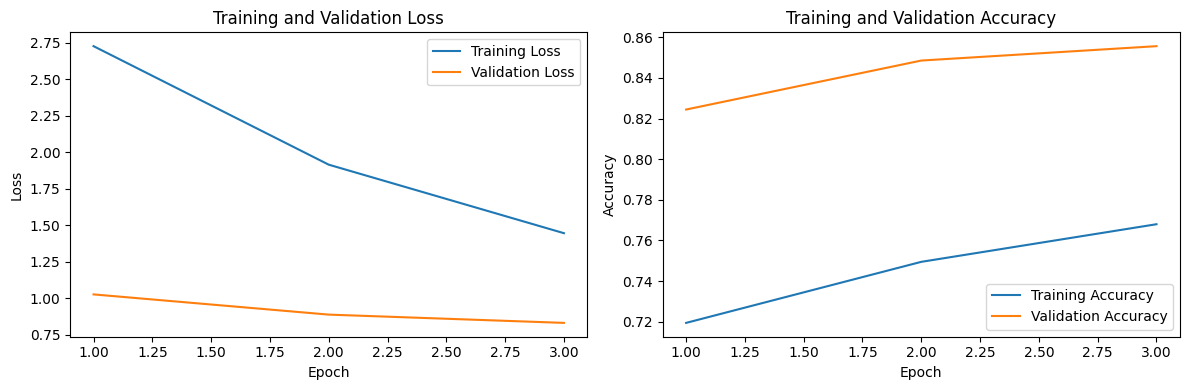

In [42]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
  """Plots the training and validation losses and accuracies."""

  epochs = range(1, len(train_losses) + 1)

  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, train_losses, label='Training Loss')
  plt.plot(epochs, val_losses, label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, train_accuracies, label='Training Accuracy')
  plt.plot(epochs, val_accuracies, label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_metrics(train_losses_t5, val_losses_t5, train_accuracies_t5, val_accuracies_t5)

In [43]:
test_size = len(dataset['test'])
subset_size = min(validation_subset_size, test_size)

small_test_data = dataset['test'].shuffle(seed=42).select(range(subset_size))

small_test_data_t5 = small_test_data.map(preprocess_data, batched=True)
small_test_data_t5.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_loader_t5 = DataLoader(small_test_data_t5, batch_size=16, shuffle=True)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:4016: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [44]:
translations_t5, references_t5 = generate_translations(fine_tuned_model_t5, test_loader_t5, fine_tuned_tokenizer_t5)

/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1249: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [45]:
bleu_score_t5 = compute_bleu_score(translations_t5, references_t5)
visualize_sample_translations(translations_t5, references_t5)
print(f"BELU Score: {bleu_score_t5:.4f}")

Sample 1:
Reference: Der Absturz des Krans kam inmitten starker Winde und Regen, nur wenige Tage vor Ankunft von Millionen im Königreich für die Pilgerreise, die mindestens einmal im Leben eines jeden gesunden Muslims erforderlich ist.
Translation: 

Sample 2:
Reference: Sie gingen mutig ran, bei ihren offensiven Bemühungen aber oft zu einfallslos zu Werke.
Translation: 

Sample 3:
Reference: Wer in der Textilbranche in Deutschland keine Nischen bedient, ist nicht mehr am Markt.
Translation: Wer aus der Textilindustrie in Deutschland, die nicht in der Lage ist, eine niche zu dienen

Sample 4:
Reference: Die Gesundheit der Weltwirtschaft ist keines der Hauptanliegen der Fed, daher sollte sie technisch bei ihrer Entscheidungsfindung nicht einbezogen werden.
Translation: Die Gesundheit der Weltwirtschaft ist nicht eine der Hauptsorgen der Fed, sondern technisch

Sample 5:
Reference: SuperCamps bestätigte, dass der Text von Camerons Mitarbeitern geliefert wurde, gab aber keine weiteren unm

In [46]:
rouge_score_t5 = compute_rouge_score(translations_t5, references_t5)
print(f"ROUGE Score: {rouge_score_t5:.4f}")

ROUGE Score: 0.2479


In [47]:
output_dir_marian = "./marian_model"
model.save_pretrained(output_dir_marian)
tokenizer.save_pretrained(output_dir_marian)

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}


('./marian_model/tokenizer_config.json',
 './marian_model/special_tokens_map.json',
 './marian_model/vocab.json',
 './marian_model/source.spm',
 './marian_model/target.spm',
 './marian_model/added_tokens.json')

Comparison of Evaluation Metrics:
       Metrics  Base Model  T5 Model
0   bleu_score    0.245430  0.062447
1  rouge_score    0.590603  0.247875


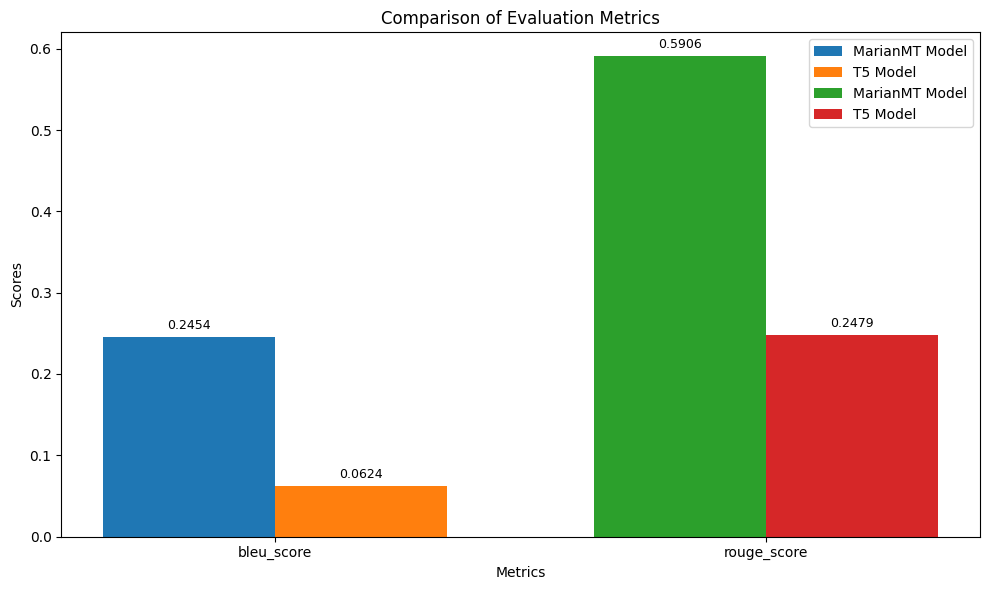

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = ['bleu_score', 'rouge_score']

base_model_scores = [bleu_score, rouge_score]
t5_model_scores = [bleu_score_t5, rouge_score_t5]

df = pd.DataFrame({
    'Metrics': metrics,
    'Base Model': base_model_scores,
    'T5 Model': t5_model_scores
})

print("Comparison of Evaluation Metrics:")
print(df)

plt.figure(figsize=(10, 6))

bar_width = 0.35

for i, metric in enumerate(metrics):
    plt.bar(i - bar_width/2, base_model_scores[i], width=bar_width, label='MarianMT Model')
    plt.bar(i + bar_width/2, t5_model_scores[i], width=bar_width, label='T5 Model')

    plt.text(i - bar_width/2, base_model_scores[i] + 0.01, f'{base_model_scores[i]:.4f}', fontsize=9, ha='center')
    plt.text(i + bar_width/2, t5_model_scores[i] + 0.01, f'{t5_model_scores[i]:.4f}', fontsize=9, ha='center')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Comparison of Evaluation Metrics')
plt.xticks(range(len(metrics)), metrics)
plt.legend()
plt.tight_layout()
plt.show()

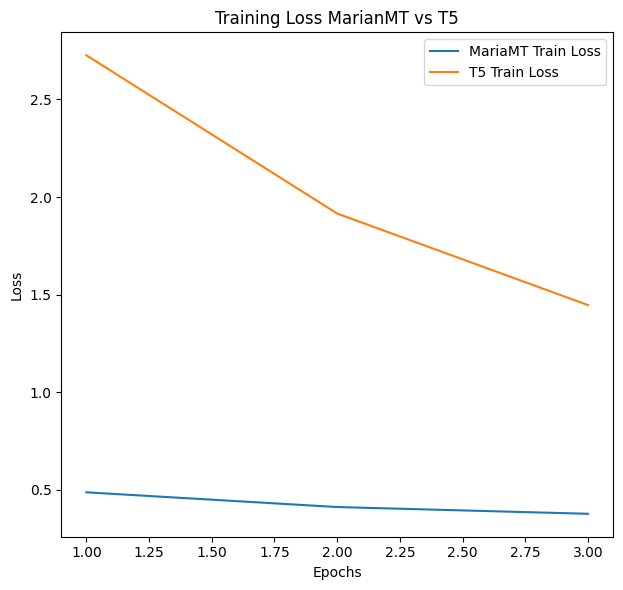

In [71]:
import matplotlib.pyplot as plt

epochs = range(1, 4)
train_losses = [0.4872, 0.4117, 0.3771]


train_losses_t5 = [2.7265, 1.9154, 1.4465]
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='MariaMT Train Loss')
plt.plot(epochs, train_losses_t5, label='T5 Train Loss')
plt.title('Training Loss MarianMT vs T5')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.tight_layout()
plt.show()

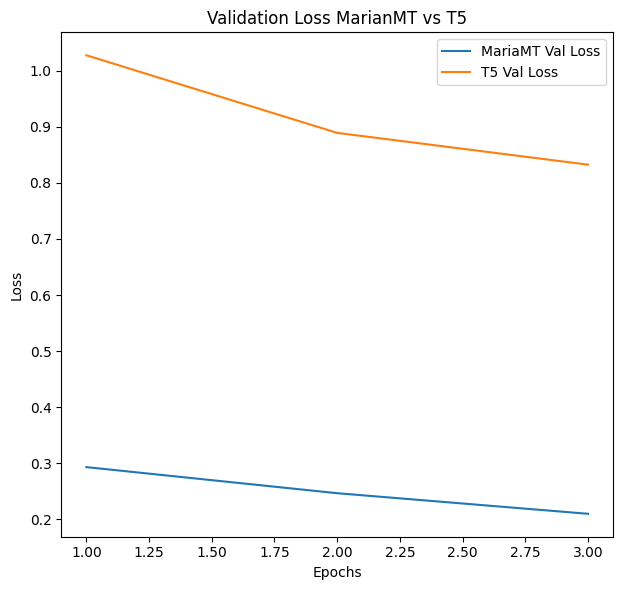

In [72]:
import matplotlib.pyplot as plt

epochs = range(1, 4)
val_losses = [0.2933, 0.2468, 0.2101]

val_losses_t5 = [1.0275, 0.8891, 0.8325]
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, val_losses, label='MariaMT Val Loss')
plt.plot(epochs, val_losses_t5, label='T5 Val Loss')
plt.title('Validation Loss MarianMT vs T5')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

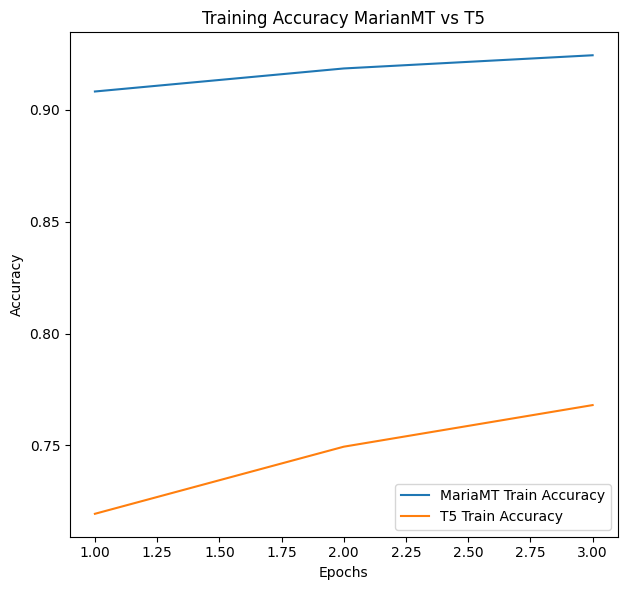

In [74]:
import matplotlib.pyplot as plt

epochs = range(1, 4)
train_accuracies = [0.9082, 0.9185, 0.9244]
train_accuracies_t5 = [0.7194, 0.7494, 0.7680]
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='MariaMT Train Accuracy')
plt.plot(epochs, train_accuracies_t5, label='T5 Train Accuracy')
plt.title('Training Accuracy MarianMT vs T5')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

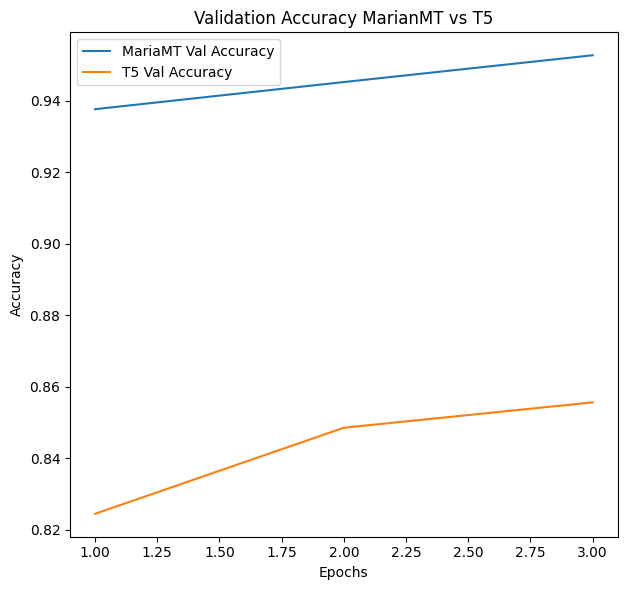

In [75]:
import matplotlib.pyplot as plt

epochs = range(1, 4)
val_accuracies = [0.9377, 0.9453, 0.9528]
val_accuracies_t5 = [0.8244, 0.8485, 0.8556]
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='MariaMT Val Accuracy')
plt.plot(epochs, val_accuracies_t5, label='T5 Val Accuracy')
plt.title('Validation Accuracy MarianMT vs T5')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

 Pickle save and download_MarianMT model

In [77]:
import pickle
with open('marian_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('marian_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [78]:
with open('marian_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('marian_tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

print(loaded_model)
print(loaded_tokenizer)

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(58101, 512, padding_idx=58100)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(58101, 512, padding_idx=58100)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [79]:
from google.colab import files
files.download('marian_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
files.download('marian_tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
import pickle
from transformers import MarianMTModel, MarianTokenizer
import torch
with open('marian_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('marian_tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
sample_sentences = [
    "Das Wetter ist heute schön.",
    "Ich habe gestern einen Film gesehen.",
    "Kannst du mir bitte helfen?"
]
inputs = loaded_tokenizer(sample_sentences, return_tensors='pt', padding=True, truncation=True)
if torch.cuda.is_available():
    device = torch.device('cuda')
    loaded_model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}
else:
    device = torch.device('cpu')
translated_outputs = loaded_model.generate(**inputs)
translated_texts = loaded_tokenizer.batch_decode(translated_outputs, skip_special_tokens=True)
for original, translated in zip(sample_sentences, translated_texts):
    print(f"Original: {original}")
    print(f"Translated: {translated}")

Original: Das Wetter ist heute schön.
Translated: Das Wetter ist heute schön.
Original: Ich habe gestern einen Film gesehen.
Translated: Ich habe gestern einen Film gesehen.
Original: Kannst du mir bitte helfen?
Translated: Kannst du mich bitte elfen?


Pickle save and download_T5 model

In [82]:
import pickle

with open('t5_model.pkl', 'wb') as f:
    pickle.dump(t5_model, f)
with open('t5_tokenizer.pkl', 'wb') as f:
    pickle.dump(t5_tokenizer, f)

In [83]:
with open('t5_model.pkl', 'rb') as f:
    loaded_t5_model = pickle.load(f)

with open('t5_tokenizer.pkl', 'rb') as f:
    loaded_t5_tokenizer = pickle.load(f)

print(loaded_t5_model)
print(loaded_t5_tokenizer)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [84]:
from google.colab import files
files.download('t5_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
files.download('t5_tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [86]:
import pickle
from transformers import MarianMTModel, MarianTokenizer
import torch
with open('marian_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('marian_tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
sample_sentences = [
    "Das Wetter ist heute schön.",
    "Ich habe gestern einen Film gesehen.",
    "Kannst du mir bitte helfen?"
]
inputs = loaded_tokenizer(sample_sentences, return_tensors='pt', padding=True, truncation=True)
if torch.cuda.is_available():
    device = torch.device('cuda')
    loaded_model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}
else:
    device = torch.device('cpu')
translated_outputs = loaded_model.generate(**inputs)
translated_texts = loaded_tokenizer.batch_decode(translated_outputs, skip_special_tokens=True)
for original, translated in zip(sample_sentences, translated_texts):
    print(f"Original: {original}")
    print(f"Translated: {translated}")

Original: Das Wetter ist heute schön.
Translated: Das Wetter ist heute schön.
Original: Ich habe gestern einen Film gesehen.
Translated: Ich habe gestern einen Film gesehen.
Original: Kannst du mir bitte helfen?
Translated: Kannst du mir bitte elfen?
